## DAMATH DYNA-Q

In [81]:
# Imports
import torch
import copy
import random
import numpy as np
from collections import defaultdict
from operator import pos
import matplotlib.pyplot as plt


In [82]:
# Auto-select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Class Environment of Damath

### Damath Board and Operations

In [83]:
class DamathEnvironment:
    def __init__(self, device='cuda'):
        self.device = device
        self.board_size = 8

        # Initial Damath board
        self.initial_board = torch.tensor([
            [  2,   0,  -5,   0,   8,   0, -11,   0],
            [  0,  -7,   0,  10,   0,  -3,   0,   0],
            [  4,   0,  -1,   0,   9,   0,  -6,   0],
            [  0,   0,   0,   0,   0,   0,   0,   0],
            [  0,   0,   0,   0,   0,   0,   0,   0],
            [  0,  -9,   0,   6,   0,  -1,   0,   4],
            [  0,   0,  -3,   0,  10,   0,  -7,   0],
            [  0, -11,   0,   8,   0,  -5,   0,   2]
        ], dtype=torch.float32, device=device)

        # Operations board
        self.operations_board = [
            ["+", "#", "÷", "#", "-", "#", "×", "#"],
            ["#", "×", "#", "+", "#", "÷", "#", "-"],
            ["-", "#", "+", "#", "÷", "#", "×", "#"],
            ["#", "÷", "#", "-", "#", "×", "#", "+"],
            ["×", "#", "÷", "#", "-", "#", "+", "#"],
            ["#", "+", "#", "÷", "#", "-", "#", "×"],
            ["÷", "#", "×", "#", "+", "#", "-", "#"],
            ["#", "-", "#", "×", "#", "+", "#", "÷"],
        ]

        self.reset()
    
    def reset(self):
        """Reset the game to initial state."""
        self.board = self.initial_board.clone()
        self.current_player = 1  # Player 1 starts
        self.scores = {1: 0, -1: 0}  # track scores separately
        return self._get_state()
    
    def _get_state(self):
        """Return current board state."""
        return self.board.clone()

    def render_board(self):
        """Pretty-print the Damath board with ops and pieces."""
        board_str = []
        for r in range(self.board_size):
            row_str = []
            for c in range(self.board_size):
                if self.operations_board[r][c] == "#":
                    row_str.append(" # ")
                    continue
                val = self.board[r, c].item()
                row_str.append(f"{int(val):3d}" if val != 0 else " . ")
            board_str.append(" ".join(row_str))
        print("\n".join(board_str))
        print(f"Scores: P1={self.scores[1]}  P2={self.scores[-1]}")

    def _apply_operation(self, piece_val, captured_val, r, c):
        op = self.operations_board[r][c]
        try:
            if op == "+":
                return piece_val + captured_val
            elif op == "-":
                return piece_val - captured_val
            elif op == "×":
                return piece_val * captured_val
            elif op == "÷":
                if captured_val == 0:
                    return None
                return int(piece_val / captured_val)  # force int like in Damath
            else:
                return piece_val
        except Exception:
            return None

    def _get_directions(self, piece):
        is_king = abs(piece) > 12
        return [(-1, -1), (-1, 1), (1, -1), (1, 1)] if is_king else (
            [(-1, -1), (-1, 1)] if piece > 0 else [(1, -1), (1, 1)]
        )

    def get_all_valid_actions(self):
        """Get all valid actions for current player."""
        actions = []
        for r in range(self.board_size):
            for c in range(self.board_size):
                piece = self.board[r, c].item()
                # Check if piece belongs to current player
                if (self.current_player > 0 and piece > 0) or (self.current_player < 0 and piece < 0):
                    moves = self.get_valid_moves((r, c))
                    for move in moves:
                        # Convert move format to action format
                        to_r, to_c, op_symbol, captured, promoted = move
                        actions.append(((r, c), (to_r, to_c), op_symbol, captured, promoted))
        return actions

    def get_valid_moves(self, pos):
        """
        Generate all valid moves for a piece at position `pos`.
        Returns list of tuples in format:
          (to_r, to_c, op_symbol, captured, promoted)
        """
        r, c = pos
        piece = self.board[r, c].item()
        if piece == 0:
            return []
        moves = []

        # Movement directions: kings move in all directions
        directions = [(-1, -1), (-1, 1)] if piece > 0 else [(1, -1), (1, 1)]
        if abs(piece) > 12:  # Damath King → all directions
            directions = [(-1, -1), (-1, 1), (1, -1), (1, 1)]

        for dr, dc in directions:
            nr, nc = r + dr, c + dc

            # --- Normal move ---
            if (
                0 <= nr < self.board_size and 0 <= nc < self.board_size
                and self.board[nr, nc].item() == 0
            ):
                op_symbol = self.operations_board[nr][nc]
                op_symbol = op_symbol if op_symbol != "#" else None
                promoted = (
                    (piece > 0 and nr == 0)
                    or (piece < 0 and nr == self.board_size - 1)
                )
                moves.append((nr, nc, op_symbol, [], promoted))

            # --- Capture move ---
            jr, jc = r + 2 * dr, c + 2 * dc
            if (
                0 <= jr < self.board_size and 0 <= jc < self.board_size
                and self.board[nr, nc].item() * piece < 0  # enemy piece in between
                and self.board[jr, jc].item() == 0          # landing square empty
            ):
                op_symbol = self.operations_board[jr][jc]
                op_symbol = op_symbol if op_symbol != "#" else None
                promoted = (
                    (piece > 0 and jr == 0)
                    or (piece < 0 and jr == self.board_size - 1)
                )
                moves.append((jr, jc, op_symbol, [(nr, nc)], promoted))

        return moves

    def step(self, action):
        """
        Apply an action to the board.
        Action format: ((from_r, from_c), (to_r, to_c), op_symbol, captured, promoted)
        Returns: (new_state, reward, done)
        """
        self.done = False  

        # Unpack action
        (from_pos, to_pos, op_symbol, captured, promoted) = action
        from_r, from_c = from_pos
        to_r, to_c = to_pos

        piece = self.board[from_r, from_c].item()
        self.board[from_r, from_c] = 0
        self.board[to_r, to_c] = piece

        reward = 0

        # Handle captures
        if captured:
            for (cr, cc) in captured:
                captured_piece = self.board[cr, cc].item()
                self.board[cr, cc] = 0
                reward += abs(captured_piece)  # scoring rule

        # Apply operation
        if op_symbol:
            if op_symbol == "+":
                reward += abs(piece)
            elif op_symbol == "-":
                reward -= abs(piece)
            elif op_symbol == "×":
                reward *= 2
            elif op_symbol == "÷" and reward != 0:
                reward //= 2

        # Handle promotion
        if promoted:
            self.board[to_r, to_c] = piece * 2  # promoted to Damath King

        # Update player scores
        self.scores[self.current_player] += reward

        # Switch turn
        self.current_player *= -1

        # Check end of game
        if not self.get_all_valid_actions():
            self.done = True

        return self.board.clone(), reward, self.done

    def parse_move(self, from_r, from_c, to_r, to_c):
        """Parse a move and return move details including captures and promotions."""
        # operation symbol at destination (None if "#")
        op_symbol = None
        if 0 <= to_r < self.board_size and 0 <= to_c < self.board_size:
            op = self.operations_board[to_r][to_c]
            op_symbol = op if op != "#" else None

        # detect captures (jumped-over piece)
        captured = []
        dr, dc = to_r - from_r, to_c - from_c
        if abs(dr) == 2 and abs(dc) == 2:
            mid_r, mid_c = from_r + dr // 2, from_c + dc // 2
            if 0 <= mid_r < self.board_size and 0 <= mid_c < self.board_size:
                if self.board[mid_r, mid_c].item() != 0:
                    captured.append((mid_r, mid_c))

        # detect promotion: check original piece and destination row
        promoted = False
        try:
            piece = self.board[from_r, from_c].item()
        except Exception:
            piece = None

        if piece is not None and piece != 0:
            # assume kings are represented by abs(value) > 12 (as in other code),
            # and promotion occurs when a non-king reaches opponent baseline
            is_king = abs(piece) > 12
            if not is_king:
                if piece > 0 and to_r == 0:
                    promoted = True
                if piece < 0 and to_r == self.board_size - 1:
                    promoted = True

        return (from_r, from_c), (to_r, to_c), op_symbol, captured, promoted

## Damath Agent

In [84]:
class DynaQAgent:
    def __init__(self, actions, planning_steps=5, alpha=0.01, gamma=0.95, epsilon=0.1):
        self.actions = actions
        self.q_table = {}
        self.planning_steps = planning_steps
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def _action_to_hashable(self, action):
        """Convert action tuple to hashable format."""
        if action is None:
            return None
        (from_pos, to_pos, op_symbol, captured, promoted) = action
        # Convert lists to tuples to make hashable
        captured_tuple = tuple(captured) if captured else ()
        return (from_pos, to_pos, op_symbol, captured_tuple, promoted)

    def _hashable_to_action(self, hashable_action):
        """Convert hashable format back to action."""
        if hashable_action is None:
            return None
        (from_pos, to_pos, op_symbol, captured_tuple, promoted) = hashable_action
        # Convert tuple back to list
        captured = list(captured_tuple) if captured_tuple else []
        return (from_pos, to_pos, op_symbol, captured, promoted)

    def choose_action(self, state, valid_actions):
        if not valid_actions:
            return None
        if np.random.rand() < self.epsilon:
            return valid_actions[np.random.randint(len(valid_actions))]
        
        # Convert actions to hashable format for Q-table lookup
        hashable_actions = [self._action_to_hashable(a) for a in valid_actions]
        q_vals = [self.q_table.get((state, ha), 0) for ha in hashable_actions]
        return valid_actions[int(np.argmax(q_vals))]

    def learn(self, state, action, reward, next_state, next_actions):
        # Convert action to hashable format
        hashable_action = self._action_to_hashable(action)
        
        old_q = self.q_table.get((state, hashable_action), 0)
        next_q = 0
        if next_actions:
            hashable_next_actions = [self._action_to_hashable(a) for a in next_actions]
            next_q = max([self.q_table.get((next_state, ha), 0) for ha in hashable_next_actions])
        
        new_q = old_q + self.alpha * (reward + self.gamma * next_q - old_q)
        self.q_table[(state, hashable_action)] = new_q

## Training Loop

Using device: cuda
Episode 1/200 - Reward: 68.0, Steps: 41
Episode 2/200 - Reward: 9.0, Steps: 42
Episode 3/200 - Reward: 23.0, Steps: 18
Episode 4/200 - Reward: 29.0, Steps: 18
Episode 5/200 - Reward: 30.0, Steps: 33
Episode 6/200 - Reward: 22.0, Steps: 42
Episode 7/200 - Reward: 50.0, Steps: 33
Episode 8/200 - Reward: -20.0, Steps: 35
Episode 9/200 - Reward: 29.0, Steps: 18
Episode 10/200 - Reward: 38.0, Steps: 28
Episode 11/200 - Reward: 48.0, Steps: 24
Episode 12/200 - Reward: 33.0, Steps: 41
Episode 13/200 - Reward: 55.0, Steps: 21
Episode 14/200 - Reward: 8.0, Steps: 25
Episode 15/200 - Reward: 31.0, Steps: 35
Episode 16/200 - Reward: 74.0, Steps: 39
Episode 17/200 - Reward: 27.0, Steps: 24
Episode 18/200 - Reward: 57.0, Steps: 29
Episode 19/200 - Reward: 83.0, Steps: 31
Episode 20/200 - Reward: 63.0, Steps: 29
Episode 21/200 - Reward: 58.0, Steps: 35
Episode 22/200 - Reward: -27.0, Steps: 40
Episode 23/200 - Reward: 43.0, Steps: 32
Episode 24/200 - Reward: 51.0, Steps: 35
Episod

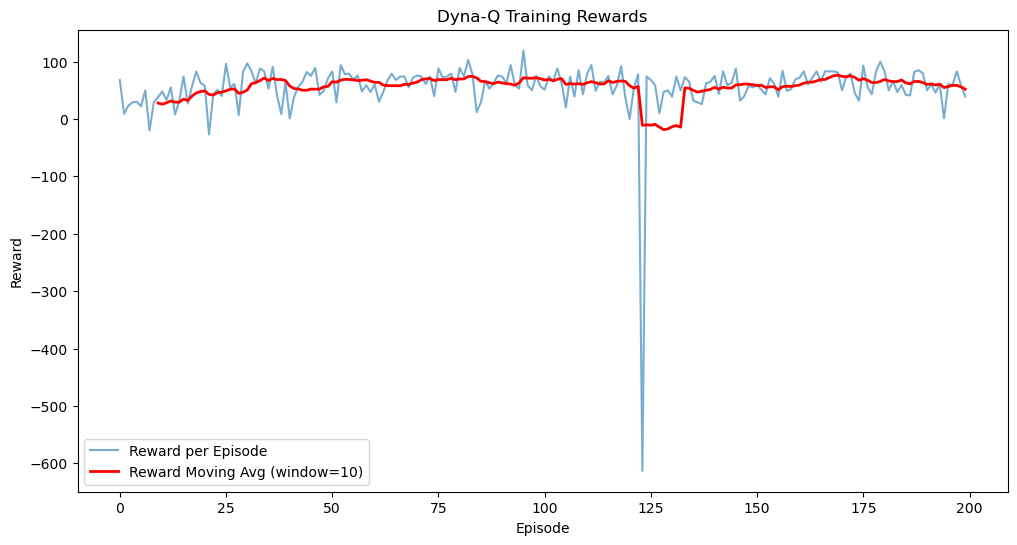

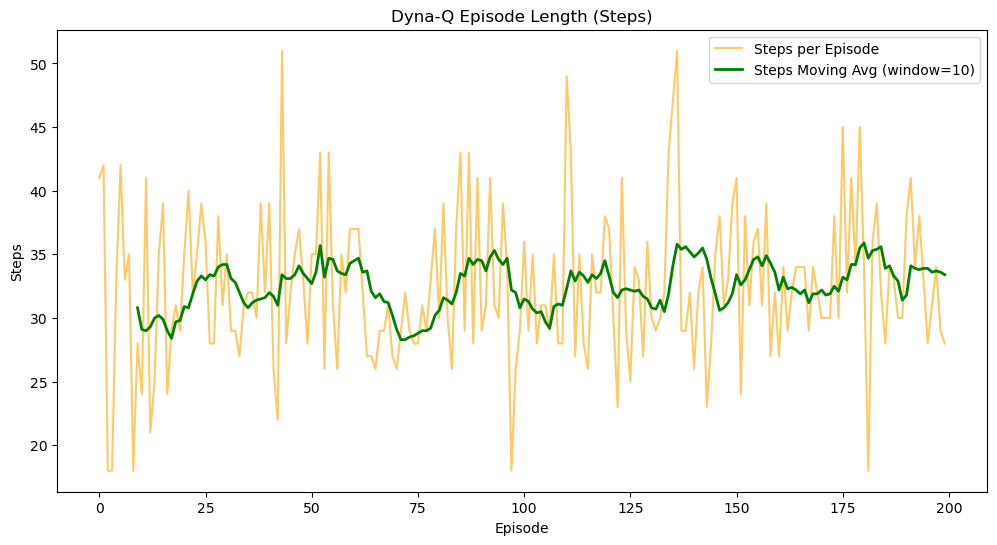

In [85]:
# --- Auto-select device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Create environment & agent ---
env = DamathEnvironment(device=device)
agent = DynaQAgent(actions=lambda s: [], planning_steps=5)

# --- Track results ---
rewards_per_episode = []
steps_per_episode = []

episodes = 200  # lower for testing
for ep in range(episodes):
    state = env.reset().to(device)
    done = False
    total_reward = 0
    steps = 0

    while not done:
        valid_actions = env.get_all_valid_actions()
        action = agent.choose_action(str(state.tolist()), valid_actions)
        if not action:
            break

        next_state, reward, done = env.step(action)
        next_state = next_state.to(device)

        total_reward += reward
        steps += 1

        next_actions = env.get_all_valid_actions()
        agent.learn(str(state.tolist()), action, reward, str(next_state.tolist()), next_actions)
        state = next_state

    rewards_per_episode.append(total_reward)
    steps_per_episode.append(steps)
    print(f"Episode {ep+1}/{episodes} - Reward: {total_reward}, Steps: {steps}")

# --- Moving averages ---
window = 10
reward_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode="valid")
steps_avg = np.convolve(steps_per_episode, np.ones(window)/window, mode="valid")

# --- Plot Rewards ---
plt.figure(figsize=(12,6))
plt.plot(rewards_per_episode, label="Reward per Episode", alpha=0.6)
plt.plot(range(window-1, episodes), reward_avg, label=f"Reward Moving Avg (window={window})", color="red", linewidth=2)
plt.xlabel("Episode"); plt.ylabel("Reward")
plt.title("Dyna-Q Training Rewards")
plt.legend(); plt.show()

# --- Plot Steps ---
plt.figure(figsize=(12,6))
plt.plot(steps_per_episode, label="Steps per Episode", alpha=0.6, color="orange")
plt.plot(range(window-1, episodes), steps_avg, label=f"Steps Moving Avg (window={window})", color="green", linewidth=2)
plt.xlabel("Episode"); plt.ylabel("Steps")
plt.title("Dyna-Q Episode Length (Steps)")
plt.legend(); plt.show()

## Sample Play

In [89]:
print("\n🎮 Sample Match after training:")
state = env.reset()
env.render_board()

done = False
step_count = 0
last_player = None  # Track who made the last move

while not done and step_count < 30:  # limit steps for readability
    step_count += 1
    current_player = env.current_player
    last_player = current_player  # store before move

    # Collect valid actions
    valid_actions = env.get_all_valid_actions()

    # Choose action
    action = agent.choose_action(str(state.tolist()), valid_actions)
    if not action:
        print(f"❌ Player {current_player} has no valid moves left!")
        break

    # Unpack action
    (from_r, from_c), (to_r, to_c), op_symbol, captured, promoted = action

    print(f"\nStep {step_count} | 🟢 Player {current_player} moves:")
    print(f"   ➡️ From ({from_r},{from_c}) → To ({to_r},{to_c})")
    
    if captured:
        if len(captured) > 1:
            print(f"   ⚔️ Combo Eat! Captured {len(captured)} pieces → {captured}")
        else:
            print(f"   ⚔️ Captured piece at {captured[0]}")
    
    if op_symbol:
        print(f"   🔢 Operation applied: {op_symbol}")

    # Apply step
    state, reward, done = env.step(action)
    env.render_board()

    if promoted:
        print("   👑 Piece promoted to DAMATH KING!")

    print(f"   🏆 Reward from action: {reward}")

# Show match result
if done:
    print("\n✅ Game Over!")
    if last_player == 1:
        winner = "Player 1"
    else:
        winner = "Player 2"
    print(f"🎉 Winner: {winner}")
else:
    print(f"\n⏰ Game stopped after {step_count} steps (demo limit reached)")



🎮 Sample Match after training:
  2  #   -5  #    8  #  -11  # 
 #   -7  #   10  #   -3  #   . 
  4  #   -1  #    9  #   -6  # 
 #   .   #   .   #   .   #   . 
 .   #   .   #   .   #   .   # 
 #   -9  #    6  #   -1  #    4
 .   #   -3  #   10  #   -7  # 
 #  -11  #    8  #   -5  #    2
Scores: P1=0  P2=0

Step 1 | 🟢 Player 1 moves:
   ➡️ From (6,4) → To (4,6)
   ⚔️ Captured piece at (5, 5)
   🔢 Operation applied: +
  2  #   -5  #    8  #  -11  # 
 #   -7  #   10  #   -3  #   . 
  4  #   -1  #    9  #   -6  # 
 #   .   #   .   #   .   #   . 
 .   #   .   #   .   #   10  # 
 #   -9  #    6  #   .   #    4
 .   #   -3  #   .   #   -7  # 
 #  -11  #    8  #   -5  #    2
Scores: P1=11.0  P2=0
   🏆 Reward from action: 11.0

Step 2 | 🟢 Player -1 moves:
   ➡️ From (1,5) → To (3,3)
   ⚔️ Captured piece at (2, 4)
   🔢 Operation applied: -
  2  #   -5  #    8  #  -11  # 
 #   -7  #   10  #   .   #   . 
  4  #   -1  #   .   #   -6  # 
 #   .   #   -3  #   .   #   . 
 .   #   .   #   .   #   10  #